# NumPy Basics -- Ch 2.1-2.2 

NumPy gives Python fast, fixed-type arrays, because plain Python lists are slow and flexible in a way that costs performance.
A Python list can hold anything — [1, "hello", 3.14, True] all in one list. This flexibility has a cost: each element is actually a full Python object carrying extra metadata (type info, reference count, size), not just the raw value. So looping over a list of a million numbers means Python is unwrapping a million little boxes each time.

A NumPy array (ndarray) fixes this by forcing every element to be the same type (usually a number), stored as raw bytes in one contiguous block of memory — like a C array.

# ch1 - Understanding Data Types

In [91]:
#create list of integers
L = list(range(10))
print(L)

type(L[0])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


int

In [92]:
#create list of strings
L2 = [str(c) for c in L]
print(L2)

type(L2[0])

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


str

In [93]:
#create heterogeneous lists
L3 = [True, "2", 3.1, 8]
[type(item) for item in L3]

[bool, str, float, int]

In [94]:
#creating arrays from python lists using np.array. NEED to run this line in order for 'np' to work
import numpy as np

#integer
np.array([1, 2, 3, 4])

#since NumPy arrays can only contain data of the same data type, if they don´t match, NumPy will upcast them
np.array([2.1, 2, 5, 4])


array([2.1, 2. , 5. , 4. ])

In [95]:
#use dtype to set dataype of resulting array
np.array([1, 2, 3, 4], dtype=np.float32)

array([1., 2., 3., 4.], dtype=float32)

In [96]:
#multidimensional array by nested loop
np.array([range(i, i + 3) for i in [2, 3, 4]])

array([[2, 3, 4],
       [3, 4, 5],
       [4, 5, 6]])

In [97]:
np.array([range(i, i+5) for i in [4, 6, 8]])

array([[ 4,  5,  6,  7,  8],
       [ 6,  7,  8,  9, 10],
       [ 8,  9, 10, 11, 12]])

In [98]:
#create a 3x5 floating-point array filled with 1s
np.ones((3, 5), dtype=float)

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [99]:
#3x5 filled with 3
np.full((3, 5), 3)

array([[3, 3, 3, 3, 3],
       [3, 3, 3, 3, 3],
       [3, 3, 3, 3, 3]])

In [100]:
#array filled with linear sequence, starting at 0, ending at 20(not included) and stepping by 2
np.arange(0, 20, 2)

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [101]:
#array 5 values evenly spaced btw 0 and 1
np.linspace(0, 1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [102]:
#3x3 array uniformly distributed, pseudorandom values(numbers that look random but are actually generated by a deterministic algorithm)
#between 0 and 1
np.random.random((3, 3))

array([[0.44069991, 0.63091715, 0.76544708],
       [0.20852127, 0.04469524, 0.59403587],
       [0.0743814 , 0.41735495, 0.63111655]])

In [103]:
#3x3 array of normally distributed pseudorandom values with mean 0 and standard deviation 1
np.random.normal(0, 1, (3, 3))

array([[-1.95203148, -0.17476676, -1.14601939],
       [-1.03277632, -0.41400954, -0.0108108 ],
       [ 0.1167361 ,  1.18917665, -0.16700843]])

In [104]:
#3x3 array of pseudorandom integers in range [0, 10)
np.random.randint(0, 10, (3, 3))

array([[9, 2, 1],
       [4, 5, 4],
       [0, 6, 7]])

In [105]:
#3x3 identity matrix
np.eye(3, 3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [106]:
#uninitialized array of 3 integers
#where values will be whatever already exist at that memory location
np.empty(3)

array([1., 1., 1.])

NUMPY STANDARD DATA TYPES

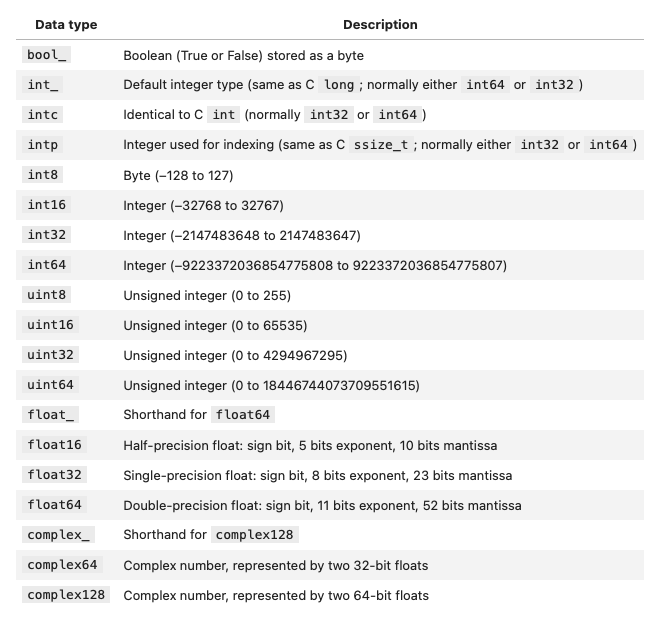

# ch2 - The basics of NumPy Arrays

NUMPY ARRAY ATTRIBUTES

Each array has attributes including:
- ndim (number of dimensions)
- shape (size of each dimension)
- size (total size of array)
- dtype (type of each element)

In [107]:
import numpy as np

#seed for reproducibility (ensure that the same random arrays are generated each time the code is run)
rng = np.random.default_rng(seed=1701)

x1 = rng.integers(10, size=6)
x2 = rng.integers(10, size=(3, 4))   #2D grid of 3 rows and 4 columns
x3 = rng.integers(10, size=(3, 4, 5))  #3 2D grids of 4 rows and 5 columns

print("x3 ndim: ", x3.ndim)
print("x3 shape: ", x3.shape)
print("x3 size: ", x3.size)
print("x3 dtype: ", x3.dtype)

x3 ndim:  3
x3 shape:  (3, 4, 5)
x3 size:  60
x3 dtype:  int64


ACCESSING SINGLE ELEMENTS

In [108]:
#first element
x1[1]
#last element
x1[-1]

#in 2D
x2[0, 0]

#modifying
x2[0, 0] = 12

ACCESSING SUBARRAYS

x[start:stop:step] - 1D

x[row_slice, column_slice] - multidimensional

In [109]:
#ONE-DIMENSIONAL

print(x1)

print(x1[:3])

print(x1[3:])

print(x1[1:4])

print(x1[::2])

print(x1[::-1])

print(x1[4:2:-1])

[9 4 0 3 8 6]
[9 4 0]
[3 8 6]
[4 0 3]
[9 0 8]
[6 8 3 0 4 9]
[8 3]


In [110]:
#MULTIDIMENSIONAL- same, with multiple slices separated by commas

print(x2)

print(x2[:2, :3]) #first two rows and three columns

print(x2[:3, ::2]) #three rows, every second column

print(x2[::-1, ::-1]) #all rows and columns reversed

print(x2[1:3, 1:3])

print(x2[:, 0]) #first column

print(x2[0, :]) #first row


[[12  1  3  7]
 [ 4  0  2  3]
 [ 0  0  6  9]]
[[12  1  3]
 [ 4  0  2]]
[[12  3]
 [ 4  2]
 [ 0  6]]
[[ 9  6  0  0]
 [ 3  2  0  4]
 [ 7  3  1 12]]
[[0 2]
 [0 6]]
[12  4  0]
[12  1  3  7]


COPIES OF ARRAYS

.copy() is used to make a copy of a subarray, so if this subarray is changed, the original stays untouched. If not used, changes in the subarray will change in the original array as well

In [116]:
# .copy()
print(x2)

x2_sub_copy = x2[:2, :2].copy()
print(x2_sub_copy)

x2_sub_copy[0, 0] = 999
print(x2_sub_copy)
print(x2)

[[99  1  3  7]
 [ 4  0  2  3]
 [ 0  0  6  9]]
[[99  1]
 [ 4  0]]
[[999   1]
 [  4   0]]
[[99  1  3  7]
 [ 4  0  2  3]
 [ 0  0  6  9]]


In [118]:
#no copy
x2
print(x2)

x2_sub = x2[:2, :2]
print(x2_sub)

x2_sub[0, 0] = 12
print(x2_sub)
print(x2)

[[99  1  3  7]
 [ 4  0  2  3]
 [ 0  0  6  9]]
[[99  1]
 [ 4  0]]
[[12  1]
 [ 4  0]]
[[12  1  3  7]
 [ 4  0  2  3]
 [ 0  0  6  9]]


RESHAPING OF ARRAYS

.reshape

In [120]:
#numbers 1 to 9 in 3x3 grid

grid = np.arange(1, 10).reshape(3, 3)
print(grid)

[[1 2 3]
 [4 5 6]
 [7 8 9]]


In [121]:
x = np.array([1, 2, 3])
x.reshape((1, 3))   #row vector via reshape

array([[1, 2, 3]])

In [ ]:
x.reshape((3, 1))   #column vector via reshape

array([[1],
       [2],
       [3]])

In [ ]:
#shortcut: use np.newaxis

x[np.newaxis, :]    #row vector via newaxis

array([[1, 2, 3]])

In [ ]:
x[:, np.newaxis]    #column vector via newaxis

array([[1],
       [2],
       [3]])

ARRAY CONCATENATION

- np.concatenate
- np.vstack and np.hstack -- used for working with arrays of mixed dimensions
- np.dstack -- stack arrays of higher-dimensions along the third axis


In [ ]:
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])
np.concatenate([x, y])   #two or more arrays

array([1, 2, 3, 4, 5, 6])

In [ ]:
#for two-dimensional arrays
grid = np.array([[1, 2, 3],
                 [4, 5, 6]])

#concatenate along the first axis
np.concatenate([grid, grid])

array([[1, 2, 3],
       [4, 5, 6],
       [1, 2, 3],
       [4, 5, 6]])

In [131]:
#concatenate along the second axis (zero-indexed)
np.concatenate([grid, grid], axis=1)

array([[1, 2, 3, 1, 2, 3],
       [4, 5, 6, 4, 5, 6]])

In [132]:
#vertically stack the arrays
np.vstack([x, grid])

array([[1, 2, 3],
       [1, 2, 3],
       [4, 5, 6]])

In [133]:
#horizontally stack the arrays
y = np.array([[99],
              [99]])
np.hstack([grid, y])

array([[ 1,  2,  3, 99],
       [ 4,  5,  6, 99]])

SPLITTING OF ARRAYS

- np.split
- np.hslip and np.vsplit
- np.dsplit -- split arrays of higher-dimensions along the third axis

In [137]:
x = [1, 2, 3, 99, 99, 3, 2, 1]
x1, x2, x3 = np.split(x, [3,5])
print(x1, x2, x3)

[1 2 3] [99 99] [3 2 1]


In [138]:
grid = np.arange(16).reshape((4, 4))
grid

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

In [140]:
upper, lower = np.vsplit(grid, [2])
print(upper)
print(lower)

[[0 1 2 3]
 [4 5 6 7]]
[[ 8  9 10 11]
 [12 13 14 15]]


In [143]:
left, right = np.hsplit(grid, [2])
print(left)
print(right)

[[ 0  1]
 [ 4  5]
 [ 8  9]
 [12 13]]
[[ 2  3]
 [ 6  7]
 [10 11]
 [14 15]]
